# Đánh giá 2 mô hình TD7
Notebook này phân tích và so sánh 2 mô hình học tăng cường được huấn luyện trên môi trường cũ và môi trường mới.

## 1. So sánh Phần thưởng Đánh giá (Evaluation Rewards)
Mỗi agent sinh ra một file `.npy` lưu trữ kết quả của nó trong suốt quá trình train. Ta sẽ vẽ hai biểu đồ này để so sánh độ hội tụ.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os
import yaml

# Cấu hình đường dẫn tới file numpy
# Lưu ý: Đổi tên file nếu bạn có các checkpoint khác
old_env_results = '/home/anhuynh/drl_agent_ws/src/src/drl_agent/temp/results/td7_agent_seed_40.npy'
new_env_results = '/home/anhuynh/drl_agent_ws/src/src/drl_agent/temp/results/td7_agent_seed_40_20260516.npy'

print("Đường dẫn mô hình cũ:", old_env_results)
print("Đường dẫn mô hình mới:", new_env_results)

Đường dẫn mô hình cũ: /home/anhuynh/drl_agent_ws/src/src/drl_agent/temp/results/td7_agent_seed_40.npy
Đường dẫn mô hình mới: /home/anhuynh/drl_agent_ws/src/src/drl_agent/temp/results/td7_agent_seed_40_20260516.npy


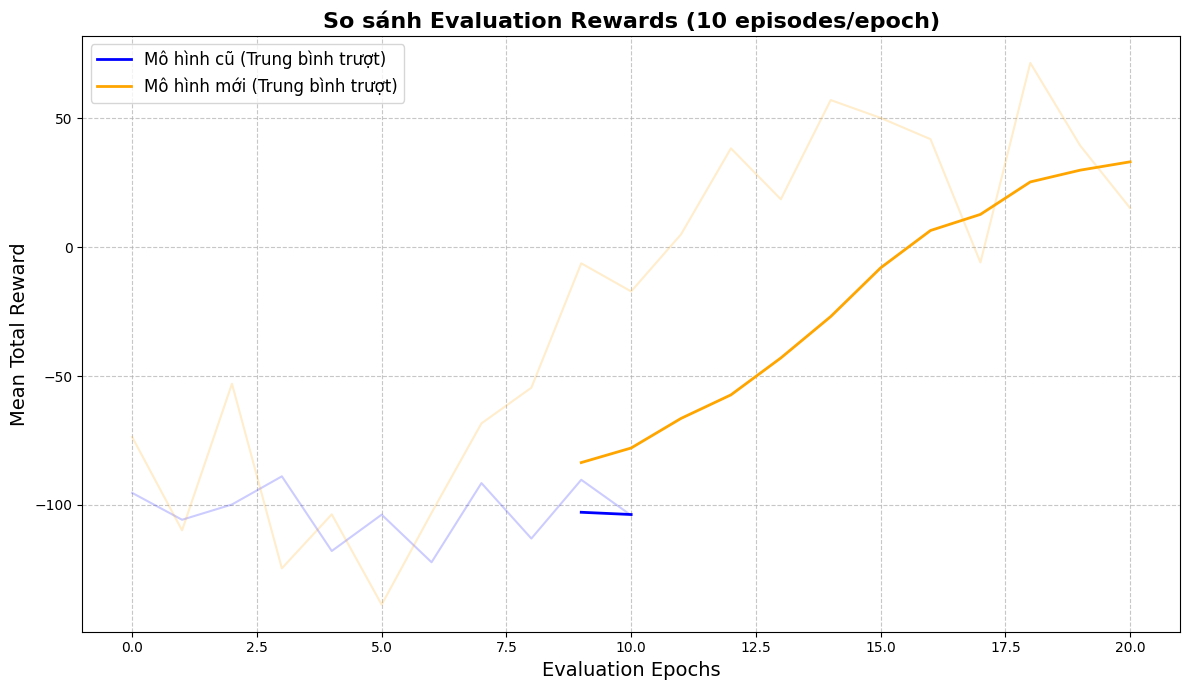

In [3]:
def plot_rewards(file1, file2, label1='Mô hình cũ', label2='Mô hình mới', window_size=10):
    if not os.path.exists(file1):
        print(f'Không tìm thấy file: {file1}')
        return
    if not os.path.exists(file2):
        print(f'Không tìm thấy file: {file2}')
        return
    
    evals1 = np.load(file1)
    evals2 = np.load(file2)
    
    # Tính running mean (trung bình trượt) để làm mượt đồ thị
    evals1_smooth = np.convolve(evals1, np.ones(window_size) / window_size, mode='valid')
    evals2_smooth = np.convolve(evals2, np.ones(window_size) / window_size, mode='valid')
    
    plt.figure(figsize=(12, 7))
    
    # Vẽ đường gốc mờ
    plt.plot(evals1, color='blue', alpha=0.2)
    plt.plot(evals2, color='orange', alpha=0.2)
    
    # Vẽ đường smooth
    plt.plot(np.arange(window_size - 1, len(evals1)), evals1_smooth, label=f'{label1} (Trung bình trượt)', color='blue', linewidth=2)
    plt.plot(np.arange(window_size - 1, len(evals2)), evals2_smooth, label=f'{label2} (Trung bình trượt)', color='orange', linewidth=2)
    
    plt.title('So sánh Evaluation Rewards (10 episodes/epoch)', fontsize=16, fontweight='bold')
    plt.xlabel('Evaluation Epochs', fontsize=14)
    plt.ylabel('Mean Total Reward', fontsize=14)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

plot_rewards(old_env_results, new_env_results)

## 2. So sánh Metrics Chạy thực tế (Testing)
Nếu bạn đã chạy `test_td7_agent.py` và xuất ra 2 file `baseline_metrics.yaml` và `ours_env_1_metrics.yaml` trong thư mục `test_runs`, đoạn code sau sẽ trực quan hóa tỷ lệ thành công (Success Rate), tỷ lệ va chạm (Collision Rate), v.v.

In [4]:
def load_metrics(metrics_file_path):
    try:
        with open(metrics_file_path, 'r') as file:
            metrics = yaml.safe_load(file)["test_metrics"]
        return metrics
    except Exception as e:
        print(f"Lỗi đọc file {metrics_file_path}: {e}")
        return None

def plot_metric(ax, metric_name, old_val, new_val, labels):
    y = np.arange(len(labels))
    height = 0.5
    
    # Vẽ bar chart
    ax.barh(0, old_val, height, color='blue', label='Mô hình cũ')
    ax.barh(1, new_val, height, color='orange', label='Mô hình mới')
    
    ax.set_yticks([0, 1])
    ax.set_yticklabels(labels, fontsize=12)
    ax.set_xlabel(metric_name.replace("_", " ").title(), fontsize=12)
    ax.set_title(f'So sánh {metric_name.replace("_", " ").title()}', fontsize=14, fontweight='bold')

def compare_test_metrics(old_yaml_file, new_yaml_file):
    old_data = load_metrics(old_yaml_file)
    new_data = load_metrics(new_yaml_file)
    
    if not old_data or not new_data:
        print("Đảm bảo bạn đã chạy test script và lưu file YAML!")
        return
    
    metric_names = ["average_distance", "average_time", "collision_rate", "success_rate"]
    labels = ["Mô hình cũ", "Mô hình mới"]
    
    fig, axs = plt.subplots(2, 2, figsize=(14, 10))
    axs = axs.flatten()
    
    for i, metric in enumerate(metric_names):
        plot_metric(axs[i], metric, old_data[metric], new_data[metric], labels)
        
    plt.tight_layout()
    plt.show()

# Đổi tên các file này thành tên file thực tế bạn đã xuất ra sau khi test trong Gazebo
old_yaml = '/home/anhuynh/drl_agent_ws/src/src/drl_agent/test_runs/baseline_metrics.yaml'
new_yaml = '/home/anhuynh/drl_agent_ws/src/src/drl_agent/test_runs/ours_env_1_metrics.yaml'
compare_test_metrics(old_yaml, new_yaml)

Lỗi đọc file /home/anhuynh/drl_agent_ws/src/src/drl_agent/test_runs/baseline_metrics.yaml: [Errno 2] No such file or directory: '/home/anhuynh/drl_agent_ws/src/src/drl_agent/test_runs/baseline_metrics.yaml'
Lỗi đọc file /home/anhuynh/drl_agent_ws/src/src/drl_agent/test_runs/ours_env_1_metrics.yaml: [Errno 2] No such file or directory: '/home/anhuynh/drl_agent_ws/src/src/drl_agent/test_runs/ours_env_1_metrics.yaml'
Đảm bảo bạn đã chạy test script và lưu file YAML!


## 3. Xem chi tiết bằng TensorBoard
Sử dụng tiện ích TensorBoard ngay trong Notebook để phân tích các đường cong loss của Actor/Critic và nhiều thông số khác.

In [5]:
%load_ext tensorboard
%tensorboard --logdir /home/anhuynh/drl_agent_ws/src/src/drl_agent/temp/logs

ModuleNotFoundError: No module named 'tensorboard'